<a href="https://colab.research.google.com/github/SUKstudent/Infotact_Data_Analytics_Internship/blob/lonali-ray/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [8]:
from google.colab import files
uploaded = files.upload()

Saving multi_touch_attribution_data (1).csv to multi_touch_attribution_data (1).csv


In [12]:
try:
    df = pd.read_csv('multi_touch_attribution_data.csv')
    print("Dataset Shape:", df.shape)
    df.head()
except FileNotFoundError:
    print("Error: 'multi_touch_attribution_data.csv' not found. Please ensure the file has been uploaded to the Colab environment by re-running the upload cell.")
    df = None # To prevent NameError if df is used later

Error: 'multi_touch_attribution_data.csv' not found. Please ensure the file has been uploaded to the Colab environment by re-running the upload cell.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     10000 non-null  int64 
 1   Timestamp   10000 non-null  object
 2   Channel     10000 non-null  object
 3   Campaign    10000 non-null  object
 4   Conversion  10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [ ]:
df.isnull().sum()

,0
User ID,0
Timestamp,0
Channel,0
Campaign,0
Conversion,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe(include='all')

,User ID,Timestamp,Channel,Campaign,Conversion
count,10000.00000,10000,10000,10000,10000
unique,NaN,9737,6,6,2
top,NaN,2025-02-11 20:29:26,Direct Traffic,-,No
freq,NaN,3,1721,3131,5056
mean,54957.01700,NaN,NaN,NaN,NaN
std,25685.14741,NaN,NaN,NaN,NaN
min,10028.00000,NaN,NaN,NaN,NaN
25%,32391.00000,NaN,NaN,NaN,NaN
50%,55446.00000,NaN,NaN,NaN,NaN
75%,77298.00000,NaN,NaN,NaN,NaN


In [ ]:
df['Channel'].value_counts()

,count
Channel,
Direct Traffic,1721
Referral,1685
Display Ads,1669
Social Media,1662
Email,1654
Search Ads,1609


In [ ]:
df['Conversion'].value_counts()

,count
Conversion,
No,5056
Yes,4944


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('multi_touch_attribution_data.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'multi_touch_attribution_data.csv'

In [17]:
from google.colab import files
uploaded = files.upload()

Saving multi_touch_attribution_data (1).csv to multi_touch_attribution_data (1) (2).csv


In [20]:
df = pd.read_csv('multi_touch_attribution_data (1).csv')

In [21]:
df.head()

,User ID,Timestamp,Channel,Campaign,Conversion
0,83281,2025-02-10 07:58:51,Email,New Product Launch,No
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,No
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,Yes
3,71026,2025-02-10 08:19:44,Direct Traffic,-,Yes
4,94486,2025-02-10 15:15:46,Email,Retargeting,Yes


In [22]:
pd.crosstab(df['Channel'], df['Conversion'])


Conversion,No,Yes
Channel,,
Direct Traffic,868,853
Display Ads,841,828
Email,824,830
Referral,844,841
Search Ads,837,772
Social Media,842,820


## Channel-wise Conversion Analysis

- Direct Traffic generated the highest number of conversions (853).
- Email was the only channel where conversions slightly exceeded non-conversions (830 vs 824).
- Search Ads recorded the lowest number of conversions (772).
- Referral traffic showed a nearly equal distribution between converted and non-converted users.
- Overall, the channels exhibited similar performance, indicating a balanced distribution of user interactions across marketing channels.

### Conclusion

Direct Traffic emerged as the top-performing channel based on total conversions, while Search Ads showed the weakest conversion performance. Email campaigns demonstrated slightly better conversion effectiveness compared to other channels.

In [23]:
conversion_rate = pd.crosstab(
    df['Channel'],
    df['Conversion'],
    normalize='index'
) * 100

conversion_rate

Conversion,No,Yes
Channel,,
Direct Traffic,50.435793,49.564207
Display Ads,50.389455,49.610545
Email,49.818622,50.181378
Referral,50.089021,49.910979
Search Ads,52.019888,47.980112
Social Media,50.661853,49.338147


## Conversion Rate Analysis

The conversion rate was calculated for each marketing channel to evaluate channel effectiveness.

### Key Findings

- Email recorded the highest conversion rate at approximately 50.18%.
- Referral and Display Ads also performed well with conversion rates close to 50%.
- Direct Traffic and Social Media showed similar conversion performance.
- Search Ads recorded the lowest conversion rate at approximately 47.98%.

### Conclusion

Email emerged as the most effective marketing channel based on conversion rate, while Search Ads showed relatively weaker performance. Overall, conversion rates across channels were fairly balanced, indicating consistent marketing performance across most channels.

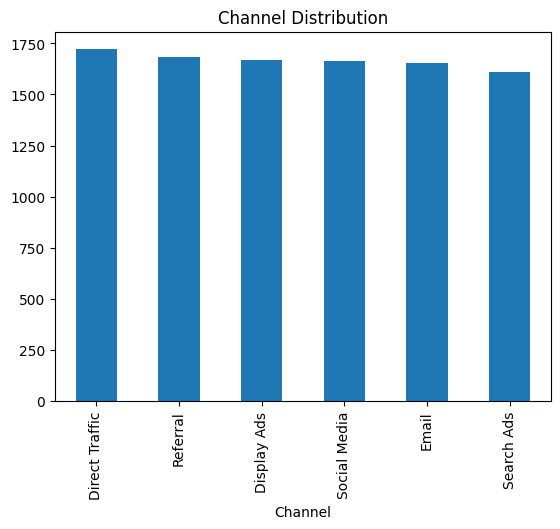

In [24]:
df['Channel'].value_counts().plot(kind='bar')
plt.title('Channel Distribution')
plt.show()

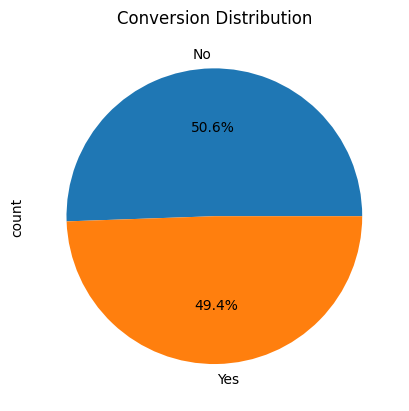

In [25]:
df['Conversion'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Conversion Distribution')
plt.show()

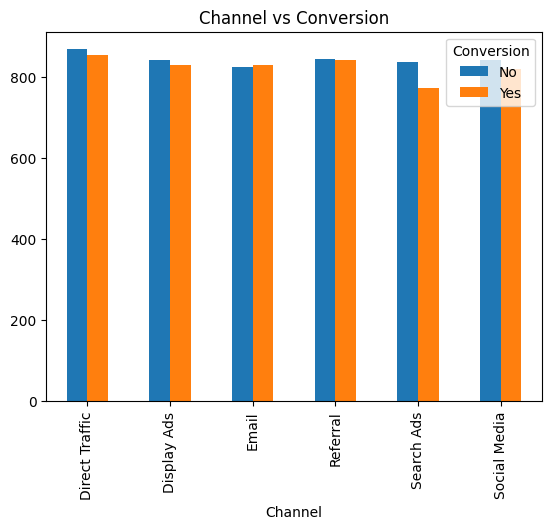

In [26]:
pd.crosstab(df['Channel'], df['Conversion']).plot(kind='bar')
plt.title('Channel vs Conversion')
plt.show()